In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from tabpfn_sbi.tasks.pyloric import PyloricTask

/home/macke/mgloeckler90/miniconda3/envs/tabpfn/lib/python3.11/site-packages/galpy/util/bovy_conversion.py:8: FutureWarning: galpy.util.bovy_conversion is being deprecated in favor of galpy.util.conversion; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9
  warnings.warn('galpy.util.bovy_conversion is being deprecated in favor of galpy.util.conversion; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9',FutureWarning)

/home/macke/mgloeckler90/miniconda3/envs/tabpfn/lib/python3.11/site-packages/galpy/util/bovy_coords.py:8: FutureWarning: galpy.util.bovy_coords is being deprecated in favor of galpy.util.coords; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9
  warnings.warn('galpy.util.bovy_coords is being deprecated in favor of galpy.util.coords; all functions in there are the same; ple

In [3]:
from tabpfn_sbi.tasks.pyloric import PyloricTask
import numpy as np

from tabpfn import TabPFNClassifier
from tabpfn_sbi.methods.tabpfn_restricted_prior import TabPFNRestrictedPrior
from tabpfn_sbi.methods.tabpfn_sbi import FilteredTabPFNSBI
from tabpfn_sbi.methods.tabpfn_support_posterior import PosteriorSupport
import torch

In [4]:
task = PyloricTask(plateau_durations=False)

/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/tasks/pyloric.py:194: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.nan_val = torch.tensor(valid_min - nan_to_num, dtype=torch.float32)



In [5]:
prior = task.get_prior_dist()

In [6]:
simulator = task.get_simulator(device="cuda")

2025-07-28 10:28:58.274044: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version (12.8.61). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Number of newly added trainable parameters: 1. Total number of trainable parameters: 9
Number of newly added trainable parameters: 1. Total number of trainable parameters: 10
Number of newly added trainable parameters: 1. Total number of trainable param

In [11]:
thetas_start, xs_start = task.get_initial_dataset()
valid_fn = task.get_is_valid_fn()

is_valid_start = valid_fn(xs_start)

In [12]:
xs_start.shape

torch.Size([50000, 15])

In [13]:
is_valid_start.sum()

tensor(557)

In [14]:
def filter_valid_best(x, theta_train, x_train, N):
    is_valid = valid_fn(x_train)
    theta_valid = theta_train[is_valid]
    x_valid = x_train[is_valid]

    std_x_valid = x_valid.std(axis=0)

    dist_x = ((x - x_valid) / std_x_valid).pow(2).sum(axis=1)
    idx = dist_x.argsort()[:N]

    return theta_valid[idx], x_valid[idx]

In [15]:
import torch

posterior = torch.load(
    "../../notebooks/posteriors3/pyloric_posterior44.pt", weights_only=False
)

In [16]:
x_o = task.get_observation(-1)

In [71]:
# Clear CUDA cache and delete unused memory
import gc

torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

samples1 = posterior.sample((10_000,), x=x_o, max_iter_rejection=1000)

In [72]:
samples = torch.concat([samples, samples1])

In [77]:
# Clear CUDA cache and delete unused memory
import gc

torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

samples2 = posterior.sample((10_000,), x=x_o, max_iter_rejection=1000)

In [78]:
# Clear CUDA cache and delete unused memory
import gc

torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

samples3 = posterior.sample((10_000,), x=x_o, max_iter_rejection=1000)

In [79]:
# Clear CUDA cache and delete unused memory
import gc

torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

samples4 = posterior.sample((10_000,), x=x_o, max_iter_rejection=1000)

In [81]:
samples = torch.concat([samples, samples2, samples3, samples4])

In [80]:
samples.shape

torch.Size([20000, 31])

In [89]:
labels_ = [
    "AB-Na    $\\;\\;$",
    "AB-CaT    $\\;\\;$",
    "AB-CaS    $\\;\\;$",
    "AB-A    $\\;\\;$",
    "AB-KCa    $\\;\\;$",
    "AB-Kd    $\\;\\;$",
    "AB-H    $\\;\\;$",
    "AB-leak    $\\;\\;$",
    "LP-Na    $\\;\\;$",
    "LP-CaT    $\\;\\;$",
    "LP-CaS    $\\;\\;$",
    "LP-A    $\\;\\;$",
    "LP-KCa    $\\;\\;$",
    "LP-Kd    $\\;\\;$",
    "LP-H    $\\;\\;$",
    "LP-leak    $\\;\\;$",
    "PY-Na    $\\;\\;$",
    "PY-CaT    $\\;\\;$",
    "PY-CaS    $\\;\\;$",
    "PY-A    $\\;\\;$",
    "PY-KCa    $\\;\\;$",
    "PY-Kd    $\\;\\;$",
    "PY-H    $\\;\\;$",
    "PY-leak    $\\;\\;$",
    "$\\mathdefault{AB-LP}$    $\\;\\;$",
    "$\\mathdefault{PD-LP}$    $\\;\\;$",
    "$\\mathdefault{AB-PY}$    $\\;\\;$",
    "$\\mathdefault{PD-PY}$    $\\;\\;$",
    "$\\mathdefault{LP-PD}$    $\\;\\;$",
    "$\\mathdefault{LP-PY}$    $\\;\\;$",
    "$\\mathdefault{PY-LP}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{Na}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{CaT}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{CaS}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{CaA}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{KCa}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{Kd}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{H}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{leak}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{glut}$    $\\;\\;$",
    "$\\mathrm{Q}_{\\mathrm{10}} \\mathrm{chol}$    $\\;\\;$",
]

all_labels = [
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{500}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{7}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{8}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{60}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{15}\\;\\;\\;$   "],
    ["$\\mathdefault{25}\\;\\;\\;$      ", "$\\mathdefault{150}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{0.0}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{0.01}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{200}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{2}\\;\\;\\;$   "],
    ["$\\mathdefault{2}\\;\\;\\;$      ", "$\\mathdefault{12}\\;\\;\\;$   "],
    ["$\\mathdefault{10}\\;\\;\\;$      ", "$\\mathdefault{60}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{10}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{125}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{0.1}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{0.0}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{600}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{12}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{4}\\;\\;\\;$   "],
    ["$\\mathdefault{30}\\;\\;\\;$      ", "$\\mathdefault{60}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{5}\\;\\;\\;$   "],
    ["$\\mathdefault{50}\\;\\;\\;$      ", "$\\mathdefault{150}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{0.1}\\;\\;\\;$   "],
    ["$\\mathdefault{0.0}\\;\\;\\;$      ", "$\\mathdefault{0.0}\\;\\;\\;$   "],
    [
        "$\\mathdefault{0.01}\\;\\;\\;\\;\\;\\;\\;$         ",
        "$\\mathdefault{10000}\\;\\;\\;\\;\\;\\;$    ",
    ],
    [
        "$\\;\\;\\mathdefault{0.01}\\;\\;\\;\\;\\;$       ",
        "$\\mathdefault{1000}\\;\\;\\;\\;\\;$  ",
    ],
    [
        "$\\;\\;\\mathdefault{0.01}\\;\\;\\;\\;\\;$       ",
        "$\\mathdefault{1000}\\;\\;\\;\\;\\;$  ",
    ],
    [
        "$\\;\\;\\mathdefault{0.01}\\;\\;\\;\\;\\;$       ",
        "$\\mathdefault{1000}\\;\\;\\;\\;\\;$  ",
    ],
    [
        "$\\;\\;\\mathdefault{0.01}\\;\\;\\;\\;\\;$       ",
        "$\\mathdefault{1000}\\;\\;\\;\\;\\;$  ",
    ],
    [
        "$\\;\\;\\mathdefault{0.01}\\;\\;\\;\\;\\;$       ",
        "  $\\mathdefault{1000}\\;\\;\\;\\;\\;$  ",
    ],
    [
        "$\\;\\;\\mathdefault{0.01}\\;\\;\\;\\;\\;$       ",
        "  $\\mathdefault{1000}\\;\\;\\;\\;\\;$  ",
    ],
]

In [83]:
lims = np.asarray(
    [
        [0.0000000e00, 5.0000000e02],
        [0.0000000e00, 7.5000000e00],
        [0.0000000e00, 8.0000000e00],
        [0.0000000e00, 6.0000000e01],
        [0.0000000e00, 1.5000000e01],
        [2.5000000e01, 1.5000000e02],
        [0.0000000e00, 2.0000000e-02],
        [0.0000000e00, 9.9999998e-03],
        [0.0000000e00, 2.0000000e02],
        [0.0000000e00, 2.5000000e00],
        [2.0000000e00, 1.2000000e01],
        [1.0000000e01, 6.0000000e01],
        [0.0000000e00, 1.0000000e01],
        [0.0000000e00, 1.2500000e02],
        [0.0000000e00, 5.9999999e-02],
        [9.9999998e-03, 3.9999999e-02],
        [0.0000000e00, 6.0000000e02],
        [0.0000000e00, 1.2500000e01],
        [0.0000000e00, 4.0000000e00],
        [3.0000000e01, 6.0000000e01],
        [0.0000000e00, 5.0000000e00],
        [5.0000000e01, 1.5000000e02],
        [0.0000000e00, 5.9999999e-02],
        [0.0000000e00, 3.9999999e-02],
        [-1.8420681e01, -4.6051702e00],
        [-1.8420681e01, -6.9077554e00],
        [-1.8420681e01, -6.9077554e00],
        [-1.8420681e01, -6.9077554e00],
        [-1.8420681e01, -6.9077554e00],
        [-1.8420681e01, -6.9077554e00],
        [-1.8420681e01, -6.9077554e00],
    ],
    dtype=np.float32,
)

/tmp/ipykernel_1684845/1865756235.py:3: DeprecationWarning: you passed deprecated arguments **kwargs: ['labelpad', 'tick_labelpad', 'tick_labels', 'fig_size', 'scatter_offdiag', 'hist_offdiag', 'plot_offdiag'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = pairplot(


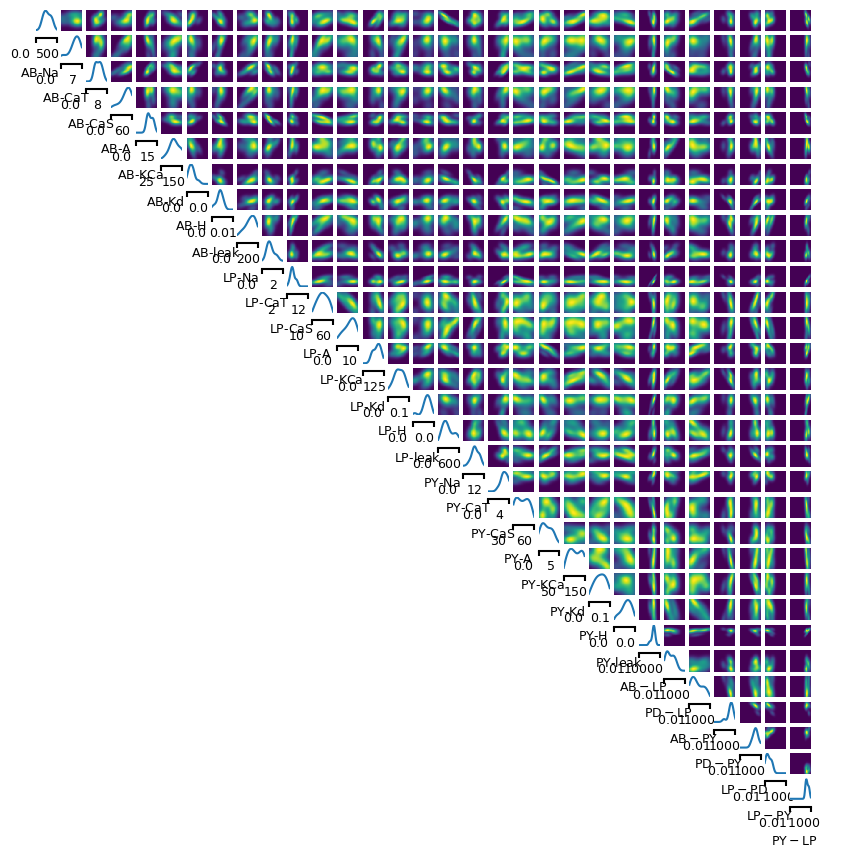

In [90]:
from sbi.analysis import pairplot

with use_style("pyloric"):
    fig, axes = pairplot(
        samples=[samples[:10]],
        labelpad=10,
        tick_labelpad=1,
        limits=lims,
        ticks=lims,
        tick_labels=all_labels,
        fig_size=(12, 12),
        labels=labels_,
        scatter_offdiag={"rasterized": True, "alpha": 1.0},
        diag=["kde"],
        upper=["kde"],
        hist_offdiag={"bins": 50},
        plot_offdiag={"linewidth": 1.6},
    )
    # fig.savefig("pyloric_posterior.svg")
    # fig.savefig("pyloric_posterior.pdf")
    # fig.savefig("pyloric_posterior.png")

In [17]:
is_valid = valid_fn(x_pred)

In [18]:
xs_valid = x_pred[is_valid]

In [19]:
xs_valid.shape

torch.Size([960, 15])

(<Figure size 2000x2000 with 225 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 5'>,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],


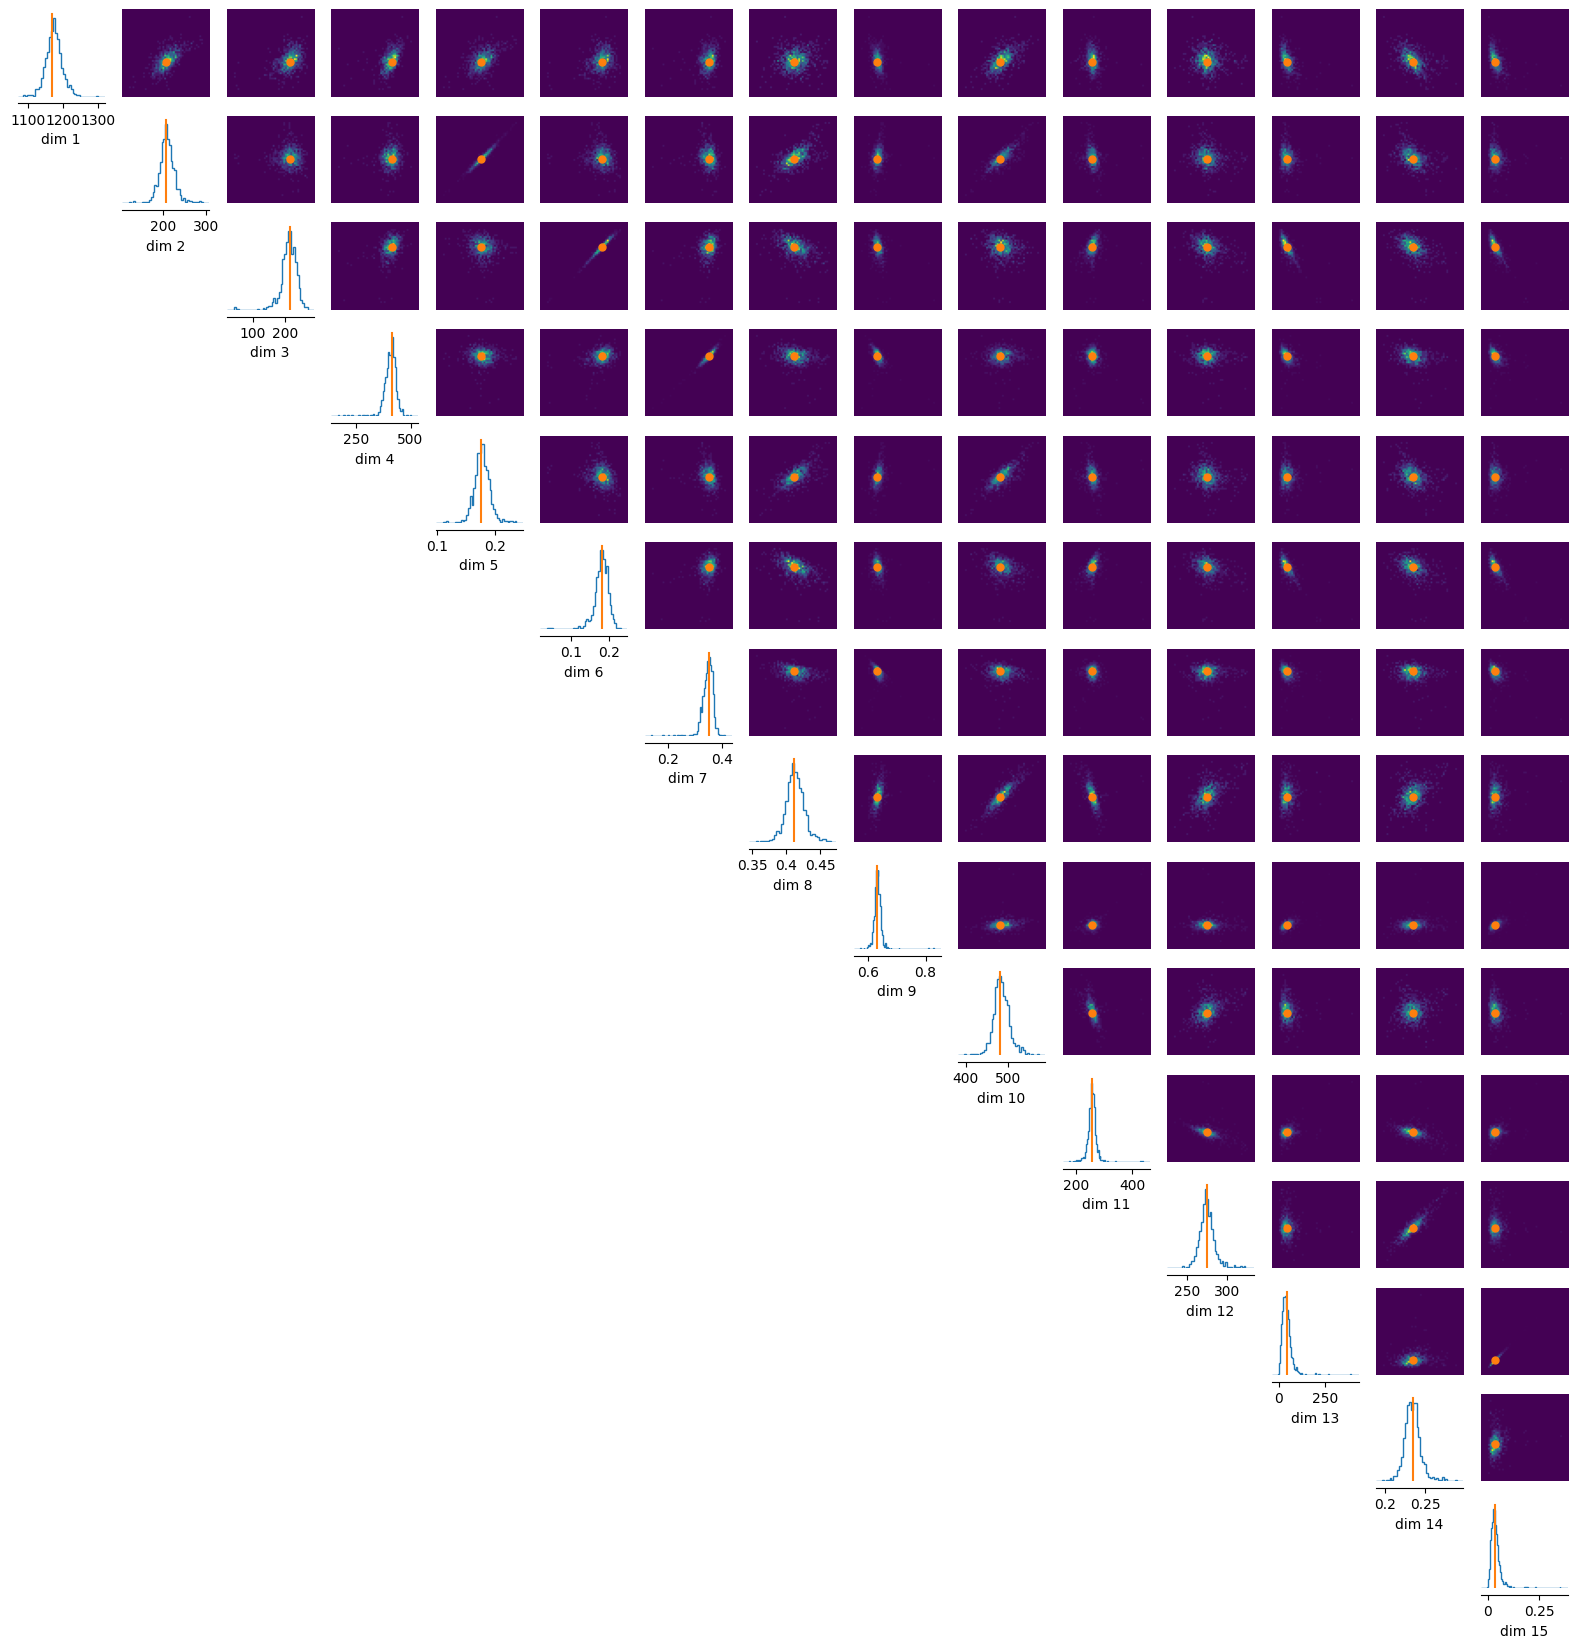

In [20]:
pairplot(xs_valid, points=x_o, figsize=(20, 20))

In [15]:
sims_tabpfn = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
results_valid_frac_tabpfn = []
results_energy_tabpfn = []
for i in range(0, 50, 5):
    frac = torch.load(
        f"posteriors_results/pyloric_valid_rate{i}.pt", weights_only=False
    )
    energy = torch.load(
        f"posteriors_results/pyloric_energy_scores{i}.pt", weights_only=False
    )
    results_valid_frac_tabpfn.append(100 * float(frac))
    results_energy_tabpfn.append(float(energy))

In [16]:
sims_tabpfn2 = [5 + v for v in range(0, 50, 5)]
results_valid_frac_tabpfn2 = []
results_energy_tabpfn2 = []
for i in list(range(0, 45, 5)) + [44]:
    frac = torch.load(
        f"posteriors_results3/pyloric_valid_rate{i}.pt", weights_only=False
    )
    energy = torch.load(
        f"posteriors_results3/pyloric_energy_scores{i}.pt", weights_only=False
    )
    results_valid_frac_tabpfn2.append(100 * float(frac))
    results_energy_tabpfn2.append(float(energy))

In [22]:
results_valid_frac_tabpfn2[3]

96.43999934196472

In [9]:
energy

tensor(0.0899)

In [ ]:
DEFAULT_COLORS

{'nle': '#76b5c5',
 'snle': '#76b5c5',
 'nre': '#1e81b0',
 'snre': '#1e81b0',
 'npe': '#1f77b4',
 'snpe': '#1f77b4',
 'tsnpe': '#1f77b2',
 'tabpfn': '#f2a900',
 'ts_tabpfn': '#f2a900',
 'filtered_tabpfn': '#f2a900',
 'filtered_tabpfn_infomax': '#f2a900'}

: 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

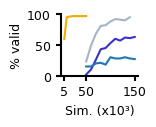

/tmp/ipykernel_1684845/2638828480.py:50: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2.)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Gene

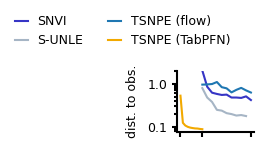

In [113]:
import matplotlib.pyplot as plt
from tabpfn_sbi.utils.plot_utils import use_style, DEFAULT_COLORS

# Extended Simulator budget (x10³)
sim_budget_extended = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
snvi_valid_extended = [2, 10, 26, 43, 45, 53, 60, 57, 62, 61, 63]
snvi_energy_extended = [2.0, 0.85, 0.62, 0.58, 0.55, 0.56, 0.48, 0.48, 0.47, 0.51, 0.42]
tsnpe_valid_extended = [15, 15, 20, 21, 18, 30, 28, 28, 30, 28, 27]
tsnpe_energy_extended = [
    0.95,
    0.96,
    0.98,
    1.09,
    0.83,
    0.78,
    0.63,
    0.72,
    0.8,
    0.7,
    0.625,
]
sim_budget_snlue = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140]
sunle_valid_extended = [23, 49, 68, 81, 82, 88, 92, 91, 90, 95]
sunle_energy_extended = [0.79, 0.48, 0.38, 0.25, 0.24, 0.21, 0.20, 0.185, 0.19, 0.18]


# Plot again with extended simulation budget
with use_style("pyloric"):
    fig = plt.figure(figsize=(1.0, 0.8))
    ax = fig.add_subplot(111)

    # Left plot (% Valid Samples)
    ax.plot(sim_budget_extended, snvi_valid_extended, label="SNVI", color="#3635c5")
    ax.plot(sim_budget_snlue, sunle_valid_extended, label="S-UNLE", color="#a6b5c5")
    ax.plot(
        sim_budget_extended,
        tsnpe_valid_extended,
        label="TSNPE (flow)",
        color=DEFAULT_COLORS["tsnpe"],
    )
    # ax.plot(sims_tabpfn, results_valid_frac_tabpfn, label='TSNAPE (TabPFN)', color=DEFAULT_COLORS["filtered_tabpfn"])
    ax.plot(
        sims_tabpfn2,
        results_valid_frac_tabpfn2,
        label="TSNAPE (TabPFN)",
        color=DEFAULT_COLORS["filtered_tabpfn"],
    )

    ax.set_xlabel("Sim. (x10³)")

    ax.set_ylabel("% valid", labelpad=3)
    ax.set_ylim(0, 100)
    ax.set_xticks([5, 50, 150])
    fig.savefig("pyloric_valid.svg", bbox_inches="tight")
plt.show()

with use_style("pyloric"):
    fig = plt.figure(figsize=(1.0, 0.8))
    ax = fig.add_subplot(111)

    # Left plot (% Valid Samples)
    ax.plot(sim_budget_extended, snvi_energy_extended, label="SNVI", color="#3635c5")
    ax.plot(sim_budget_snlue, sunle_energy_extended, label="S-UNLE", color="#a6b5c5")
    ax.plot(
        sim_budget_extended,
        tsnpe_energy_extended,
        label="TSNPE (flow)",
        color=DEFAULT_COLORS["tsnpe"],
    )
    # ax.plot(sims_tabpfn, results_energy_tabpfn, label='TSNPE (TabPFN)', color=DEFAULT_COLORS["filtered_tabpfn"])
    ax.plot(
        sims_tabpfn2,
        results_energy_tabpfn2,
        label="TSNPE (TabPFN)",
        color=DEFAULT_COLORS["filtered_tabpfn"],
    )
    # ax.set_xlabel('Sim. (x10³)')
    ax.set_xticks([5, 50, 150])
    ax.set_xticklabels([])
    ax.set_ylabel("dist. to obs.", labelpad=6)
    ax.set_yscale("log")
    ax.set_ylim(0, 2.0)
    ax.set_yticks([0.1, 1.0])
    ax.set_yticklabels(["0.1", "1.0"])
    ax.legend(
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(-0.7, 1.2),
        handlelength=1,
        handleheight=0.5,
    )
    fig.savefig("pyloric_energy.svg", bbox_inches="tight")
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

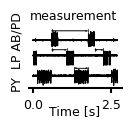

In [41]:
import seaborn as sns

npz = np.load("trace_data_845_082_0044.npz")
t = npz["t"]
PD_spikes = npz["PD_spikes"]
LP_spikes = npz["LP_spikes"]
PY_spikes = npz["PY_spikes"]
pdn = npz["pdn"]
lpn = npz["lpn"]
pyn = npz["pyn"]
start_index = 219500 + 2100
end_index = 246500 + 2100  # 32000
height_offset = 200
shown_t = t[end_index] - t[start_index]
time_len = shown_t / 0.025 * 1000
dt = t[1] - t[0]
t = t - t[start_index]

with use_style("pyloric"):
    fig = plt.figure(figsize=(1.2, 0.8))
    ax = fig.add_subplot(111)

    ax.plot(
        t[start_index:end_index],
        0.8 + pdn[start_index:end_index] * 0.0015,
        c="k",
        lw=0.8,
    )
    ax.plot(
        t[start_index:end_index],
        0.6 + lpn[start_index:end_index] * 0.075,
        c="k",
        lw=0.8,
    )
    ax.plot(
        t[start_index:end_index],
        0.33 + pyn[start_index:end_index] * 0.0035,
        c="k",
        lw=0.8,
    )

    linew = 0.2
    headl = 0.06
    headw = 0.02
    linelen = 0.02
    circlefact = 0.2

    # period arrow
    height1 = 0.92
    ax.arrow(
        t[start_index] + 0.6,
        height1,
        1.15,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.arrow(
        t[start_index] + 1.75,
        height1,
        -1.15,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.plot(
        [t[start_index] + 0.6, t[start_index] + 0.6],
        [height1 - linelen, height1 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    ax.plot(
        [t[start_index] + 1.75, t[start_index] + 1.75],
        [height1 - linelen, height1 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    # patch =mp.Ellipse((t[start_index]+1.2, 3.65), 0.2*circlefact,0.6*circlefact, color='lightgray')
    # ax.add_patch(patch)

    # delay arrow
    height2 = 0.67
    ax.arrow(
        t[start_index] + 0.6,
        height2,
        0.48,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.arrow(
        t[start_index] + 1.08,
        height2,
        -0.48,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.plot(
        [t[start_index] + 0.6, t[start_index] + 0.6],
        [height2 - linelen, height2 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    ax.plot(
        [t[start_index] + 1.08, t[start_index] + 1.08],
        [height2 - linelen, height2 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    # patch =mp.Ellipse((t[start_index]+0.94, 2.1), 0.2*circlefact,0.6*circlefact, color='lightgray')
    # ax.add_patch(patch)

    # gap arrow
    ax.arrow(
        t[start_index] + 1.98,
        height2,
        0.27,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.arrow(
        t[start_index] + 2.25,
        height2,
        -0.27,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.plot(
        [t[start_index] + 1.98, t[start_index] + 1.98],
        [height2 - linelen, height2 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    ax.plot(
        [t[start_index] + 2.25, t[start_index] + 2.25],
        [height2 - linelen, height2 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    # patch =mp.Ellipse((t[start_index]+2.1, 2.1), 0.2*circlefact,0.6*circlefact, color='lightgray')
    # ax.add_patch(patch)

    # duration arrow
    height4 = 0.43
    ax.arrow(
        t[start_index] + 1.33,
        height4,
        0.43,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.arrow(
        t[start_index] + 1.76,
        height4,
        -0.43,
        0,
        shape="full",
        head_width=headw,
        head_length=headl,
        length_includes_head=True,
        color="k",
        lw=linew,
    )
    ax.plot(
        [t[start_index] + 1.33, t[start_index] + 1.33],
        [height4 - linelen, height4 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    ax.plot(
        [t[start_index] + 1.76, t[start_index] + 1.76],
        [height4 - linelen, height4 + linelen],
        c="k",
        lw=linew * 2.5,
    )
    # patch =mp.Ellipse((t[start_index]+1.55, 0.9), radius=0.2, color='lightgray')
    # ax.add_patch(patch)

    # plt.xticks([0., 0.5, 1., 1.5, 2., 2.5])
    # ax.set_yticks([0.33,0.58,0.81])
    # ax.set_yticklabels(["PY","LP", "AB\nPD"])
    ax.set_yticks([])
    ax.set_xticks([0.0, 2.5])
    ax.set_xticklabels(ax.get_xticklabels())
    # ax.set_ylim(0.2,1.)
    ax.set_ylabel("   PY" + "  LP " + "AB/PD")

    ax.set_xlabel("Time [s]", labelpad=-5)
    # ax.text(0.5, 1.0, "Empirical observation", transform=ax.transAxes, horizontalalignment="center")

    sns.despine(fig, left=True)

    # ax = plt.gca()
    ax.tick_params(axis="y", length=0)
    fig.suptitle(r"$x_o$")
    fig.suptitle("measurement", y=1.1)
    fig.savefig("xo.svg", transparent=True)

    plt.show()

In [42]:
simulator_voltage = task.get_simulator(type="voltage")

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Number of newly added trainable parameters: 1. Total number of trainable parameters: 9
Number of newly added trainable parameters: 1. Total number of trainable parameters: 10
Number of newly added trainable parameters: 1. Total number of trainable param

In [44]:
# x_o = task.get_observation(-1)
# samples = posterior.sample((1_000,), x=x_o, max_iter_rejection=1000)

In [45]:
xs_pred = simulator_voltage(samples.mean(0, keepdim=True).repeat(2, 1))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

2500000.0


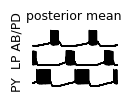

In [48]:
with use_style("pyloric"):
    fig = plt.figure(figsize=(1.2, 0.8))
    ax = fig.add_subplot(111)

    start_index = 240000
    end_index = 340000
    length = end_index - start_index

    print(length * 0.025 * 1000)
    ax.plot(3.0 + xs_pred[0, 0][start_index:end_index] * 0.01, c="k", lw=0.8)
    ax.plot(1.5 + xs_pred[0, 1][start_index:end_index] * 0.01, c="k", lw=0.8)
    ax.plot(0.0 + xs_pred[0, 2][start_index:end_index] * 0.01, c="k", lw=0.8)
    ax.set_yticks([])
    ax.set_xticks([])
    sns.despine(fig, left=True, bottom=True)
    ax.set_ylabel("   PY" + "  LP " + "AB/PD")

    fig.suptitle("posterior mean", y=1.1)
    fig.savefig("posterior_mean.svg", transparent=True)
    plt.show()

In [38]:
from functools import partial
from tabpfn_sbi.tasks.pyloric import PyloricTask
from tabpfn_sbi.methods.tabpfn_restricted_prior import TabPFNRestrictedPrior
from tabpfn_sbi.methods.tabpfn_sbi import FilteredTabPFNSBI
from tabpfn_sbi.methods.tabpfn_support_posterior import PosteriorSupport
import torch
import os
import wandb
import numpy as np
from tabpfn.model.multi_head_attention import set_flex_attention

set_flex_attention(False)


seed = 0
torch.manual_seed(0)
np.random.seed(0)
torch.cuda.manual_seed_all(0)


task = PyloricTask(plateau_durations=False)
prior = task.get_prior_dist()

simulator = task.get_simulator(device="cuda")

thetas_start, xs_start = task.get_initial_dataset()
valid_fn = task.get_is_valid_fn()

is_valid_start = valid_fn(xs_start)

xs_std = xs_start[is_valid_start].std(axis=0)


def standardized_dist(x, x_train):
    return torch.mean(((x - x_train) / xs_std).pow(2).sum(axis=1))


def filter_valid_best(x, theta_train, x_train, N):
    is_valid = valid_fn(x_train)
    theta_valid = theta_train[is_valid]
    x_valid = x_train[is_valid]

    std_x_valid = x_valid.std(axis=0)

    dist_x = ((x - x_valid) / std_x_valid).pow(2).sum(axis=1)
    idx = dist_x.argsort()[:N]

    return theta_valid[idx], x_valid[idx]


# Real observation
x_o = task.get_observation(-1).cpu()
x_mean, x_std = task.get_valid_x_mean_std()


def energy_scoring_rule(X, x):
    beta = 1
    X_z = (X - x_mean) / x_std
    x_z = (x - x_mean) / x_std
    term_1 = (
        2
        / X.shape[0]
        * torch.sum(torch.sqrt(torch.sum(torch.square(X_z - x_z), axis=-1)))
    )
    term_2 = (
        1
        / (X.shape[0] * (X.shape[0] - 1))
        * torch.sum(
            torch.sqrt(
                torch.sum(torch.square(X_z[:, None, :] - X_z[None, :, :]), axis=-1)
            )
        )
    )
    return term_1 - term_2


posterior = torch.load(
    f"../../notebooks/posteriors3/pyloric_posterior44.pt", weights_only=False
)
samples = posterior.sample((1_000,), x=x_o, max_iter_rejection=2)
xs_pred = simulator(samples)
is_valid = valid_fn(xs_pred)
valid_rate = torch.sum(is_valid) / xs_pred.shape[0]
xs_pred_valid = xs_pred[is_valid]
energy_scores = energy_scoring_rule(xs_pred_valid, x_o)
print(energy_scores, valid_rate)

/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/tasks/pyloric.py:194: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.nan_val = torch.tensor(valid_min - nan_to_num, dtype=torch.float32)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7

In [ ]:
from functools import partial
from tabpfn_sbi.tasks.pyloric import PyloricTask
from tabpfn_sbi.methods.tabpfn_restricted_prior import TabPFNRestrictedPrior
from tabpfn_sbi.methods.tabpfn_sbi import FilteredTabPFNSBI
from tabpfn_sbi.methods.tabpfn_support_posterior import PosteriorSupport
import torch
import os
import wandb
import numpy as np
from tabpfn.model.multi_head_attention import set_flex_attention

set_flex_attention(False)


seed = 0
torch.manual_seed(0)
np.random.seed(0)
torch.cuda.manual_seed_all(0)


task = PyloricTask(plateau_durations=False)
prior = task.get_prior_dist()

simulator = task.get_simulator(device="cuda")

thetas_start, xs_start = task.get_initial_dataset()
valid_fn = task.get_is_valid_fn()

is_valid_start = valid_fn(xs_start)

xs_std = xs_start[is_valid_start].std(axis=0)


def standardized_dist(x, x_train):
    return torch.mean(((x - x_train) / xs_std).pow(2).sum(axis=1))


def filter_valid_best(x, theta_train, x_train, N):
    is_valid = valid_fn(x_train)
    theta_valid = theta_train[is_valid]
    x_valid = x_train[is_valid]

    std_x_valid = x_valid.std(axis=0)

    dist_x = ((x - x_valid) / std_x_valid).pow(2).sum(axis=1)
    idx = dist_x.argsort()[:N]

    return theta_valid[idx], x_valid[idx]


# Real observation
x_o = task.get_observation(-1).cpu()
x_mean, x_std = task.get_valid_x_mean_std()


def energy_scoring_rule(X, x):
    beta = 1
    X_z = (X - x_mean) / x_std
    x_z = (x - x_mean) / x_std
    term_1 = (
        2
        / X.shape[0]
        * torch.sum(torch.sqrt(torch.sum(torch.square(X_z - x_z), axis=-1)))
    )
    term_2 = (
        1
        / (X.shape[0] * (X.shape[0] - 1))
        * torch.sum(
            torch.sqrt(
                torch.sum(torch.square(X_z[:, None, :] - X_z[None, :, :]), axis=-1)
            )
        )
    )
    return term_1 - term_2


posterior = torch.load(
    f"../../notebooks/posteriors3/pyloric_posterior44.pt", weights_only=False
)
permutation = torch.randperm(31)
posterior.append_simulations(
    posterior._theta_train[..., permutation], posterior._x_train
)
posterior.prior = torch.distributions.Independent(
    torch.distributions.Uniform(
        posterior.prior.base_dist.low[..., permutation],
        posterior.prior.base_dist.high[..., permutation],
    ),
    1,
)
samples = posterior.sample((1_000,), x=x_o, max_iter_rejection=2)
# Invert permutation
permutation = torch.argsort(permutation)
samples = samples[..., permutation]
xs_pred = simulator(samples)
is_valid = valid_fn(xs_pred)
valid_rate = torch.sum(is_valid) / xs_pred.shape[0]
xs_pred_valid = xs_pred[is_valid]
energy_scores = energy_scoring_rule(xs_pred_valid, x_o)
print(energy_scores, valid_rate)

/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/tasks/pyloric.py:194: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.nan_val = torch.tensor(valid_min - nan_to_num, dtype=torch.float32)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7

: 

In [7]:
import torch
import matplotlib.pyplot as plt

import pickle


energy_scores_list0 = pickle.load(open("scripts/energy_scores_list_0.pkl", "rb"))
energy_scores_list1 = pickle.load(open("scripts/energy_scores_list_1.pkl", "rb"))
energy_scores_list2 = pickle.load(open("scripts/energy_scores_list_2.pkl", "rb"))
energy_scores_list3 = pickle.load(open("scripts/energy_scores_list_3.pkl", "rb"))
energy_scores_list4 = pickle.load(open("scripts/energy_scores_list_4.pkl", "rb"))

valid_rates_list0 = pickle.load(open("scripts/valid_rates_list_0.pkl", "rb"))
valid_rates_list1 = pickle.load(open("scripts/valid_rates_list_1.pkl", "rb"))
valid_rates_list2 = pickle.load(open("scripts/valid_rates_list_2.pkl", "rb"))
valid_rates_list3 = pickle.load(open("scripts/valid_rates_list_3.pkl", "rb"))
valid_rates_list4 = pickle.load(open("scripts/valid_rates_list_4.pkl", "rb"))

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0.,
        0., 1., 2., 0., 2., 0., 0., 2., 2., 0., 2., 1., 1., 0., 2., 0., 0.,
        1., 0., 0., 1., 1., 0., 2., 0., 2., 1., 0., 0., 1., 0., 1., 0., 1.,
        2., 2., 3., 0., 0., 3., 0., 0., 0., 2., 0., 0., 2., 0., 1., 0., 0.,
        1., 1., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.07842819, 0.07865727, 0.07888634, 0.07911541, 0.07934448,
        0.07957356, 0.07980262, 0.0800317 , 0.08026078, 0.08048984,
        0.08071892, 0.08094799, 0.08117706, 0.08140614, 0.08163521,
        0.08186428, 0.08209335, 0.08232243, 0.08255149, 0.08278057,
        0.08300965, 0.08323871, 0.08346779, 0.08369686, 0.08392593,
        0.08415501, 0.08438408, 0.08461315, 0.08484222, 0.0850713 ,
        0.08530036, 0.08552944, 0.08575851, 0.08598758, 0.08621666,
        0.08644573, 0.0866748 , 0.08690387, 0.08713295, 0.08736202,
      

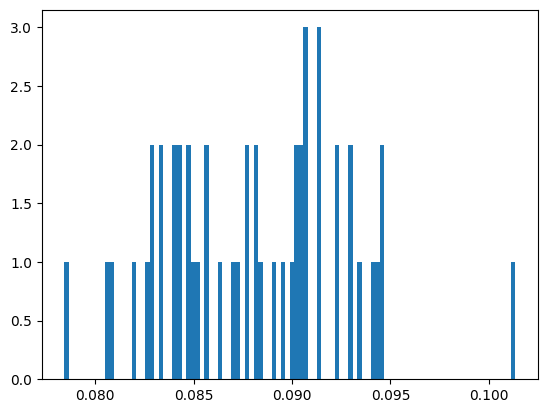

In [6]:
import numpy as np

energy_scores = np.array(
    energy_scores_list0
    + energy_scores_list1
    + energy_scores_list2
    + energy_scores_list3
    + energy_scores_list4
)
plt.hist(energy_scores, bins=100)

In [12]:
print(np.quantile(energy_scores, 0.05), np.quantile(energy_scores, 0.95))

0.08137248456478119 0.09442034587264062


(array([1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 2., 0., 0., 1., 0., 0., 0., 0., 4., 0., 0.,
        4., 0., 0., 2., 0., 4., 0., 0., 4., 0., 0., 5., 0., 3., 0., 0., 1.,
        0., 0., 3., 0., 3., 0., 0., 2., 0., 0., 3., 0., 0., 1., 0., 3., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.94800001, 0.94837004, 0.94874001, 0.94911003, 0.94948   ,
        0.94985002, 0.95021999, 0.95059001, 0.95096004, 0.95133001,
        0.95170003, 0.95207   , 0.95244002, 0.95280999, 0.95318002,
        0.95355004, 0.95392001, 0.95429003, 0.95466   , 0.95503002,
        0.95539999, 0.95577002, 0.95614004, 0.95651001, 0.95688003,
        0.95725   , 0.95762002, 0.95798999, 0.95836002, 0.95873004,
        0.95910001, 0.95947003, 0.95984   , 0.96021003, 0.96057999,
        0.96095002, 0.96132004, 0.96169001, 0.96206003, 0.96243   ,
      

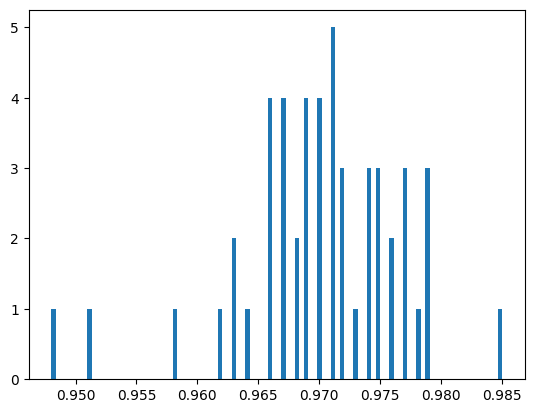

In [8]:
import numpy as np

valid_rates = np.array(
    valid_rates_list0
    + valid_rates_list1
    + valid_rates_list2
    + valid_rates_list3
    + valid_rates_list4
)
plt.hist(valid_rates, bins=100)

In [11]:
print(np.quantile(valid_rates, 0.05), np.quantile(valid_rates, 0.95))

0.9598000079393387 0.9789999723434448
